In [1]:
import os
import pickle
from utils.plots import get_clause_lengths_by_polarity, plot_clause_length_boxplot_by_polarity, plot_literal_clause_frequency
import matplotlib.pyplot as plt
import numpy as np
import config
from utils.statistics import compute_clause_length_statistics, run_mannwhitney_pos_neg_length, run_kruskalwallis_across_specialists, run_posthoc_mannwhitney

In [2]:
CURRENT_DATASET = config.BLOODMNIST

In [3]:
canny_path = os.path.join("saved_models", "BloodMNIST_Canny_Specialist.pkl")
with open(canny_path, "rb") as f:
    tm_canny = pickle.load(f)
    

tm_gaussian = os.path.join("saved_models", "BloodMNIST_Adaptive_Gaussian_Specialist.pkl")
with open(tm_gaussian, "rb") as f:
    tm_gaussian = pickle.load(f)

tn_mean = os.path.join("saved_models", "BloodMNIST_Adaptive_Mean_Specialist.pkl") 
with open(tn_mean, "rb") as f:
    tm_mean = pickle.load(f)

tm_otsu = os.path.join("saved_models", "BloodMNIST_Otsu_Specialist.pkl")
with open(tm_otsu, "rb") as f:
    tm_otsu = pickle.load(f)

tm_thermo = os.path.join("saved_models", "BloodMNIST_Color_Thermometers_Specialist.pkl")
with open(tm_thermo, "rb") as f:
    tm_thermo = pickle.load(f)

In [4]:
specialists = {
    'Canny': tm_canny,
    'Ad. Gaussian': tm_gaussian,
    'Ad. Mean': tm_mean,
    'Otsu': tm_otsu,
    'Thermometer': tm_thermo,
}

In [5]:
for name, tm in specialists.items():
   print(f"========={name}")
   print(f"Number of Clauses for: {tm.number_of_clauses}")
   print(f"The Patch size is {tm.patch_dim}")
   print(f"The T value is {tm.T}")
   print(f"The s value is {tm.s}")
   print(f"The max included literals is {tm.max_included_literals}")
   print()

=========Canny
Number of Clauses for: 4000
The Patch size is (7, 7)
The T value is 9000
The s value is 6.0
The max included literals is 32

=========Ad. Gaussian
Number of Clauses for: 4000
The Patch size is (7, 7)
The T value is 6500
The s value is 5.0
The max included literals is 32

=========Ad. Mean
Number of Clauses for: 4000
The Patch size is (7, 7)
The T value is 5000
The s value is 8.0
The max included literals is 32

=========Otsu
Number of Clauses for: 4000
The Patch size is (9, 9)
The T value is 3500
The s value is 13.0
The max included literals is 64

=========Thermometer
Number of Clauses for: 4000
The Patch size is (9, 9)
The T value is 7500
The s value is 3.0
The max included literals is 64




--- Clause Length Observations: BreastMNIST | Class 0 ---
  Canny                     Positive:   2000  |  Negative:   2000
  Ad. Gaussian              Positive:   2000  |  Negative:   2000
  Ad. Mean                  Positive:   2000  |  Negative:   2000
  Otsu                      Positive:   2000  |  Negative:   2000
  Thermometer               Positive:   2000  |  Negative:   2000
------------------------------------------------------------
Saved to clause_analysis_plots/blood_clause_length_boxplot_class_0.svg


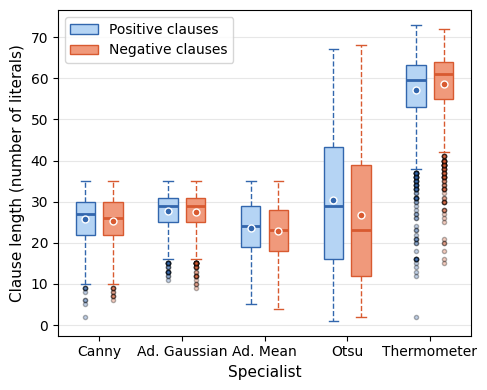


--- Clause Length Observations: BreastMNIST | Class 1 ---
  Canny                     Positive:   2000  |  Negative:   2000
  Ad. Gaussian              Positive:   2000  |  Negative:   2000
  Ad. Mean                  Positive:   2000  |  Negative:   2000
  Otsu                      Positive:   2000  |  Negative:   2000
  Thermometer               Positive:   1998  |  Negative:   2000
------------------------------------------------------------
Saved to clause_analysis_plots/blood_clause_length_boxplot_class_1.svg


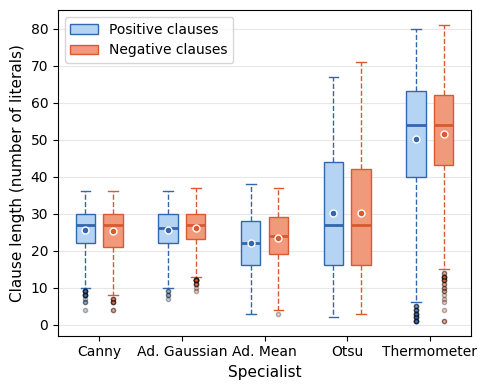


--- Clause Length Observations: BreastMNIST | Class 2 ---
  Canny                     Positive:   2000  |  Negative:   2000
  Ad. Gaussian              Positive:   2000  |  Negative:   2000
  Ad. Mean                  Positive:   2000  |  Negative:   2000
  Otsu                      Positive:   2000  |  Negative:   2000
  Thermometer               Positive:   2000  |  Negative:   2000
------------------------------------------------------------
Saved to clause_analysis_plots/blood_clause_length_boxplot_class_2.svg


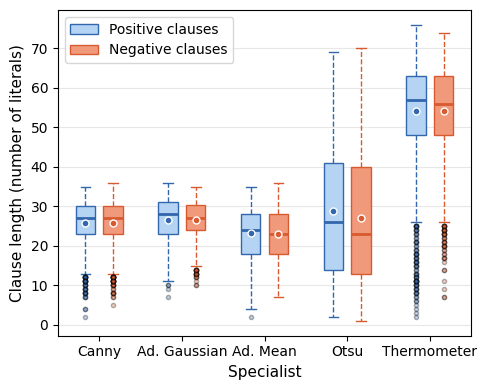


--- Clause Length Observations: BreastMNIST | Class 3 ---
  Canny                     Positive:   2000  |  Negative:   2000
  Ad. Gaussian              Positive:   2000  |  Negative:   2000
  Ad. Mean                  Positive:   2000  |  Negative:   2000
  Otsu                      Positive:   2000  |  Negative:   2000
  Thermometer               Positive:   2000  |  Negative:   2000
------------------------------------------------------------
Saved to clause_analysis_plots/blood_clause_length_boxplot_class_3.svg


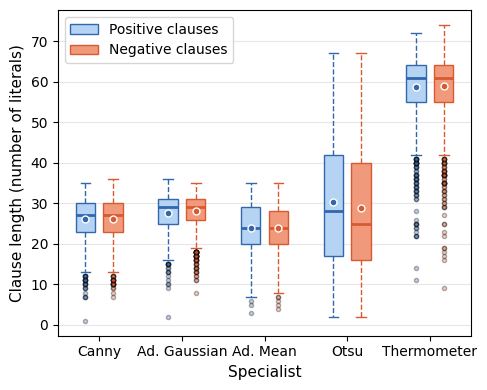


--- Clause Length Observations: BreastMNIST | Class 4 ---
  Canny                     Positive:   2000  |  Negative:   2000
  Ad. Gaussian              Positive:   2000  |  Negative:   2000
  Ad. Mean                  Positive:   2000  |  Negative:   2000
  Otsu                      Positive:   2000  |  Negative:   2000
  Thermometer               Positive:   2000  |  Negative:   2000
------------------------------------------------------------
Saved to clause_analysis_plots/blood_clause_length_boxplot_class_4.svg


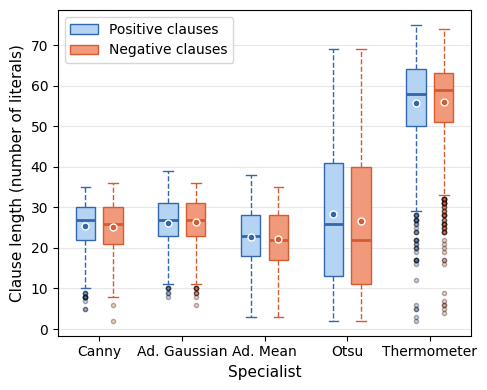


--- Clause Length Observations: BreastMNIST | Class 5 ---
  Canny                     Positive:   2000  |  Negative:   2000
  Ad. Gaussian              Positive:   2000  |  Negative:   2000
  Ad. Mean                  Positive:   2000  |  Negative:   2000
  Otsu                      Positive:   2000  |  Negative:   2000
  Thermometer               Positive:   2000  |  Negative:   2000
------------------------------------------------------------
Saved to clause_analysis_plots/blood_clause_length_boxplot_class_5.svg


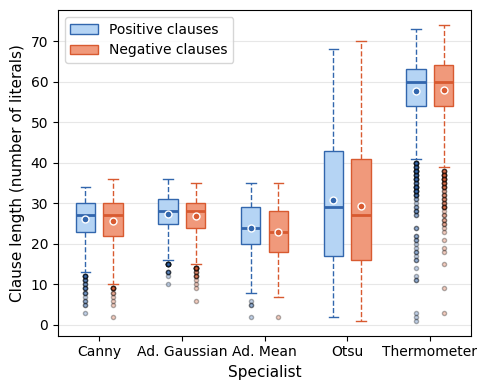


--- Clause Length Observations: BreastMNIST | Class 6 ---
  Canny                     Positive:   2000  |  Negative:   2000
  Ad. Gaussian              Positive:   2000  |  Negative:   2000
  Ad. Mean                  Positive:   2000  |  Negative:   2000
  Otsu                      Positive:   2000  |  Negative:   2000
  Thermometer               Positive:   2000  |  Negative:   2000
------------------------------------------------------------
Saved to clause_analysis_plots/blood_clause_length_boxplot_class_6.svg


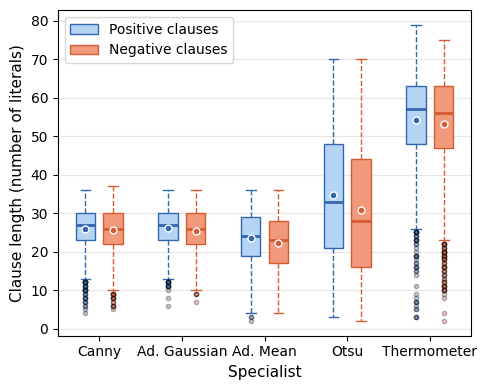


--- Clause Length Observations: BreastMNIST | Class 7 ---
  Canny                     Positive:   2000  |  Negative:   2000
  Ad. Gaussian              Positive:   2000  |  Negative:   2000
  Ad. Mean                  Positive:   2000  |  Negative:   2000
  Otsu                      Positive:   2000  |  Negative:   2000
  Thermometer               Positive:   1990  |  Negative:   2000
------------------------------------------------------------
Saved to clause_analysis_plots/blood_clause_length_boxplot_class_7.svg


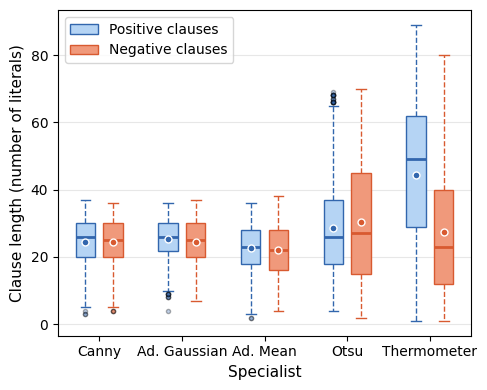

In [6]:
for target_class in [0, 1, 2, 3, 4, 5, 6, 7]:
    data_pos = {}
    data_neg = {}
    for name, tm in specialists.items():
        pos, neg = get_clause_lengths_by_polarity(tm, target_class)
        data_pos[name] = pos
        data_neg[name] = neg

    plot_clause_length_boxplot_by_polarity(
        data_pos, data_neg,
        target_class=target_class,
        figsize=(5, 4), 
        fontsize_ticks=10,
        save_path=os.path.join("clause_analysis_plots", f"{CURRENT_DATASET}_clause_length_boxplot_class_{target_class}.svg")
    )

In [7]:
for target_class in [0, 1, 2, 3, 4, 5, 6, 7]:
    data_pos = {}
    data_neg = {}
    for name, tm in specialists.items():
        pos, neg = get_clause_lengths_by_polarity(tm, target_class)
        data_pos[name] = pos
        data_neg[name] = neg
    compute_clause_length_statistics(data_pos, data_neg, dataset_name='BloodMNIST', target_class=target_class)


Clause Length Statistics | BloodMNIST | Class 0
  Specialist                Polarity          n       Mean     Median        Std
  ------------------------- ------------ ------ ---------- ---------- ----------
  Canny                     Positive       2000      25.66      27.00       5.50
                            Negative       2000      25.40      26.00       5.63
  ------------------------- ------------ ------ ---------- ---------- ----------
  Ad. Gaussian              Positive       2000      27.81      29.00       4.35
                            Negative       2000      27.46      29.00       4.50
  ------------------------- ------------ ------ ---------- ---------- ----------
  Ad. Mean                  Positive       2000      23.54      24.00       6.10
                            Negative       2000      22.87      23.00       6.21
  ------------------------- ------------ ------ ---------- ---------- ----------
  Otsu                      Positive       2000      30.36  


Clause Length Statistics | BloodMNIST | Class 4
  Specialist                Polarity          n       Mean     Median        Std
  ------------------------- ------------ ------ ---------- ---------- ----------
  Canny                     Positive       2000      25.51      27.00       5.58
                            Negative       2000      25.08      26.00       5.91
  ------------------------- ------------ ------ ---------- ---------- ----------
  Ad. Gaussian              Positive       2000      26.13      27.00       5.43
                            Negative       2000      26.42      27.00       5.25
  ------------------------- ------------ ------ ---------- ---------- ----------
  Ad. Mean                  Positive       2000      22.78      23.00       6.51
                            Negative       2000      22.29      22.00       6.47
  ------------------------- ------------ ------ ---------- ---------- ----------
  Otsu                      Positive       2000      28.42  

In [8]:
for target_class in [0, 1, 2, 3, 4, 5, 6, 7]:
    data_pos = {}
    data_neg = {}  # make sure these are reset inside the loop
    for name, tm in specialists.items():
        pos, neg = get_clause_lengths_by_polarity(tm, target_class)
        data_pos[name] = pos
        data_neg[name] = neg
    run_mannwhitney_pos_neg_length(data_pos, data_neg, dataset_name='BloodMNIST', target_class=target_class)


Mann-Whitney U — Positive vs Negative Clause Lengths
Dataset: BloodMNIST | Class 0
H0: Positive and negative clause length distributions are identical.
H1: Positive and negative clause length distributions differ.

  Specialist                 n_pos  n_neg     U-stat      p-value   Effect (r)  Reject H0
  ------------------------- ------ ------ ---------- ------------ ------------ ----------
  Canny                       2000   2000  2049353.5        0.176      -0.0247          ✗
  Ad. Gaussian                2000   2000  2089558.0        0.014      -0.0448          ✓
  Ad. Mean                    2000   2000  2125190.5     6.00e-04      -0.0626          ✓
  Otsu                        2000   2000  2263550.0     5.27e-13      -0.1318          ✓
  Thermometer                 2000   2000  1806299.5     1.09e-07       0.0969          ✓

  Significance level: α = 0.05


Mann-Whitney U — Positive vs Negative Clause Lengths
Dataset: BloodMNIST | Class 1
H0: Positive and negative clause leng

In [9]:
for target_class in [0, 1, 2, 3, 4, 5, 6, 7]:
    data_pos = {}
    data_neg = {}
    for name, tm in specialists.items():
        pos, neg = get_clause_lengths_by_polarity(tm, target_class)
        data_pos[name] = pos
        data_neg[name] = neg

    run_kruskalwallis_across_specialists(
        data_pos, data_neg,
        dataset_name='BloodMNIST',
        target_class=target_class
    )


Kruskal-Wallis — Clause Lengths Across Specialists
Dataset: BloodMNIST | Class 0
H0: Clause length distributions are identical across all specialists.
H1: At least one specialist has a different clause length distribution.

  Polarity      H-statistic      p-value  Reject H0
  ------------ ------------ ------------ ----------
  Positive        4525.9550       0.0000          ✓
  Negative        4700.5493       0.0000          ✓

  Significance level: α = 0.05


Kruskal-Wallis — Clause Lengths Across Specialists
Dataset: BloodMNIST | Class 1
H0: Clause length distributions are identical across all specialists.
H1: At least one specialist has a different clause length distribution.

  Polarity      H-statistic      p-value  Reject H0
  ------------ ------------ ------------ ----------
  Positive        3096.2480       0.0000          ✓
  Negative        3435.2698       0.0000          ✓

  Significance level: α = 0.05


Kruskal-Wallis — Clause Lengths Across Specialists
Dataset: BloodMN

In [10]:
for target_class in [0, 1, 2, 3, 4, 5, 6, 7]:
    data_pos = {}
    data_neg = {}
    for name, tm in specialists.items():
        pos, neg = get_clause_lengths_by_polarity(tm, target_class)
        data_pos[name] = pos
        data_neg[name] = neg
    run_posthoc_mannwhitney(
        data_pos, data_neg,
        dataset_name='BloodMNIST',
        target_class=target_class
    )  



Post-hoc Pairwise Mann-Whitney U — Across Specialists
Dataset: BloodMNIST | Class 0
H0: Clause length distributions are identical for a given pair of specialists.
H1: Clause length distributions differ for a given pair of specialists.

--- Positive clauses ---
  Pair                                              U-stat        p-value   Effect (r)  Reject H0
  --------------------------------------------- ---------- -------------- ------------ ----------
  Canny vs Ad. Gaussian                          1544459.5       6.85e-36       0.2278          ✓
  Canny vs Ad. Mean                              2412662.0       1.09e-29      -0.2063          ✓
  Canny vs Otsu                                  1753317.0       1.39e-11       0.1233          ✓
  Canny vs Thermometer                             46504.0       0.00e+00       0.9767          ✓
  Ad. Gaussian vs Ad. Mean                       2831695.0      3.14e-115      -0.4158          ✓
  Ad. Gaussian vs Otsu                           192